## Libraries

In [10]:
%pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl (46.2 MB)
Note: you may need to restart the kernel to use updated packages.


In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

## Data Loading and Preprocessing

In [13]:
IMG_SIZE = 128

def load_data(image_dir, mask_dir):
    images = []
    masks = []

    img_files = sorted(os.listdir(image_dir))

    for img_name in img_files:
        img_path = os.path.join(image_dir, img_name)
        mask_name = img_name.replace(".jpg", ".png")
        mask_path = os.path.join(mask_dir, mask_name)

        # Load image
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        # Load mask
        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = (mask > 0).astype(np.float32)

        images.append(img)
        masks.append(mask)

    images = np.array(images)
    masks = np.array(masks)

    # Add channel to mask
    masks = np.expand_dims(masks, axis=-1)

    return images, masks

In [31]:
X_train, y_train = load_data(
    "./data/segmentation_task/train/images/",
    "./data/segmentation_task/train/masks/"
)

## U-Net Architecture

In [16]:
def unet_model():
    inputs = layers.Input((128, 128, 3))

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)

    # Decoder
    u1 = layers.UpSampling2D()(c3)
    u1 = layers.concatenate([u1, c2])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c1])
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c5)

    model = models.Model(inputs, outputs)
    return model

## Dice Loss

In [29]:
import tensorflow as tf

def dice_loss(y_true, y_pred):
    smooth = 1e-6
    intersection = tf.reduce_sum(y_true * y_pred)
    return 1 - (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)


# Dice loss is a loss function used primarily for semantic image segmentation
# to measure the overlap between predicted segmentation and ground truth

## Compile Model

In [24]:
model = unet_model()

model.compile(
    optimizer='adam',
    loss=lambda y_true, y_pred: tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred),
    metrics=['accuracy']
)

## Train Model

In [23]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=8
)

Epoch 1/20
 20/492 ━━━━━━━━━━━━━━━━━━━━ 2:09 275ms/step - accuracy: 0.9945 - loss: 0.1740

KeyboardInterrupt: 

## Prediction

In [20]:
pred = model.predict(X_train[0:1])[0]
pred_bin = pred > 0.3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step


## Visualization

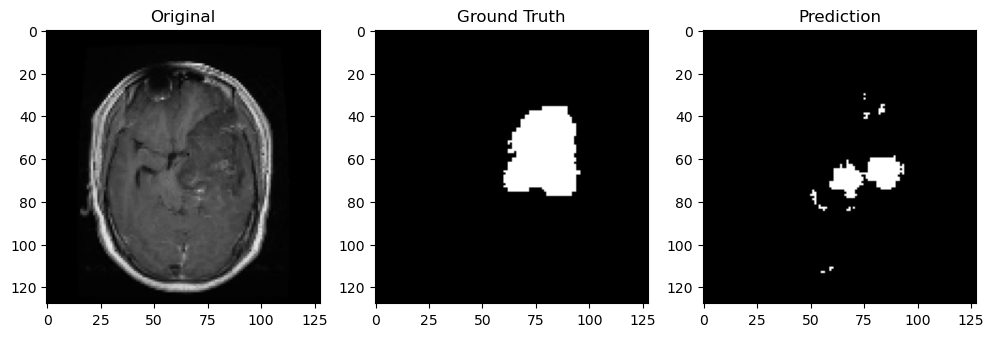

In [22]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_train[0])
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(y_train[0].squeeze(), cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_bin.squeeze(), cmap='gray')
plt.title("Prediction")
plt.show()

# **Improvement**

## Better Loss Weighting

In [32]:
model = unet_model()

model.compile(
    optimizer='adam',
    loss = lambda y_true, y_pred: 0.5 * tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred),
    metrics=['accuracy']
)

## Increasing epoch number to 40

In [33]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=8
)

Epoch 1/40
492/492 ━━━━━━━━━━━━━━━━━━━━ 141s 283ms/step - accuracy: 0.9709 - loss: 0.8022
Epoch 2/40
492/492 ━━━━━━━━━━━━━━━━━━━━ 139s 282ms/step - accuracy: 0.9824 - loss: 0.5389
Epoch 3/40
492/492 ━━━━━━━━━━━━━━━━━━━━ 138s 280ms/step - accuracy: 0.9855 - loss: 0.4491
Epoch 4/40
492/492 ━━━━━━━━━━━━━━━━━━━━ 138s 280ms/step - accuracy: 0.9869 - loss: 0.4071
Epoch 5/40
492/492 ━━━━━━━━━━━━━━━━━━━━ 136s 276ms/step - accuracy: 0.9880 - loss: 0.3699
Epoch 6/40
492/492 ━━━━━━━━━━━━━━━━━━━━ 138s 280ms/step - accuracy: 0.9885 - loss: 0.3495
Epoch 7/40
492/492 ━━━━━━━━━━━━━━━━━━━━ 136s 277ms/step - accuracy: 0.9892 - loss: 0.3238
Epoch 8/40
492/492 ━━━━━━━━━━━━━━━━━━━━ 133s 270ms/step - accuracy: 0.9899 - loss: 0.3050
Epoch 9/40
492/492 ━━━━━━━━━━━━━━━━━━━━ 133s 271ms/step - accuracy: 0.9903 - loss: 0.2891
Epoch 10/40
492/492 ━━━━━━━━━━━━━━━━━━━━ 132s 267ms/step - accuracy: 0.9905 - loss: 0.2796
Epoch 11/40
492/492 ━━━━━━━━━━━━━━━━━━━━ 133s 270ms/step - accuracy: 0.9911 - loss: 0.2621
Epoch 12

In [34]:
pred = model.predict(X_train[0:1])[0]
pred_bin = pred > 0.3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Text(0.5, 1.0, 'Prediction')

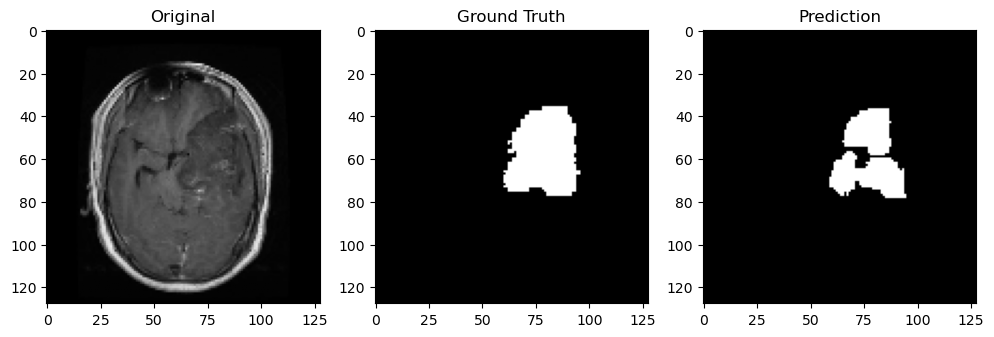

In [35]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_train[0])
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(y_train[0].squeeze(), cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_bin.squeeze(), cmap='gray')
plt.title("Prediction")